# RQ4: Abstention utility of semantic entropy on CADEC
## SIT723 — Masters Research Techniques and Applications

**Dataset:** CADEC (patient-generated health text). Do **not** relabel as clinical notes.

**Input:** `outputs/rq3/entropy_cadec.csv` (from the CADEC entropy pipeline),
including `mapping_confidence` (original-input SapBERT/FAISS cosine).

**This run:** four clean models only — BERT-base, BioBERT, PubMedBERT, FLAN-T5-base.
Instruct generative models are excluded until chat-template-corrected entropy is regenerated.

**Three abstention arms per model:** semantic entropy (low first), mapping confidence
(high first), random.

**Outputs:**
- `outputs/rq3/rq4_risk_coverage_cadec.csv`
- `outputs/rq3/figures/rq4_risk_coverage_cadec.png`

## RQ4 statement and hypothesis

**Research question (RQ4):** Can UMLS-grounded semantic entropy work as an abstention
signal that improves reliability of retained predictions on CADEC
(patient-generated health text)?

**Hypothesis:** Ranking instances by semantic entropy and abstaining on the
highest-entropy fraction yields a more favourable risk–coverage trade-off (lower AURC)
than abstaining by mapping confidence or at random, and selective accuracy at reduced
coverage exceeds full-coverage accuracy.

In [1]:
# === RQ4 LOAD (CADEC entropy + mapping_confidence) ============================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = Path(".").resolve()

OUT_DIR = PROJECT_ROOT / "outputs" / "rq3"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_CADEC = OUT_DIR / "entropy_cadec.csv"
if not PATH_CADEC.exists():
    raise FileNotFoundError(
        f"RQ4 requires {PATH_CADEC}. Run the CADEC entropy pipeline first."
    )

# Clean encoder / FLAN models only for this run (instruct generatives pending re-run)
CLEAN_MODELS = ["BERT-base", "BioBERT", "PubMedBERT", "FLAN-T5-base"]

df_raw = pd.read_csv(PATH_CADEC)
required = [
    "instance_id", "model_name", "domain", "pair",
    "normalised_entropy", "m_accepted", "accuracy", "mapping_confidence",
    "dominant_cui", "n_unassigned",
]
_missing_cols = [c for c in required if c not in df_raw.columns]
if _missing_cols:
    raise KeyError(f"{PATH_CADEC} missing columns: {_missing_cols}")

print(f"Loaded CADEC (patient-generated health text) entropy: {PATH_CADEC}")
print(f"  rows={len(df_raw):,} | all models: {sorted(df_raw['model_name'].unique())}")

df = df_raw[df_raw["model_name"].isin(CLEAN_MODELS)].copy()
print(f"Filtered to clean models {CLEAN_MODELS}: rows={len(df):,}")

n_nan_h = int(df["normalised_entropy"].isna().sum())
n_nan_c = int(df["mapping_confidence"].isna().sum())
df = df.dropna(subset=["normalised_entropy", "mapping_confidence"]).copy()
df["accuracy"] = df["accuracy"].astype(float)
df["mapping_confidence"] = df["mapping_confidence"].astype(float)
print(
    f"Dropped NaN: entropy={n_nan_h:,} confidence={n_nan_c:,} | "
    f"analysis rows={len(df):,}"
)
print(
    df.groupby("model_name").agg(
        n=("instance_id", "size"),
        mean_H=("normalised_entropy", "mean"),
        mean_acc=("accuracy", "mean"),
        mean_conf=("mapping_confidence", "mean"),
        std_conf=("mapping_confidence", "std"),
    ).loc[CLEAN_MODELS].round(4)
)

Loaded CADEC (patient-generated health text) entropy: /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/entropy_cadec.csv
  rows=45,352 | all models: ['BERT-base', 'BioBERT', 'BioMistral-7B', 'FLAN-T5-base', 'Llama3-OpenBioLLM-8B', 'Meta-Llama-3-8B-Instruct', 'Mistral-7B-Instruct-v0.1', 'PubMedBERT']
Filtered to clean models ['BERT-base', 'BioBERT', 'PubMedBERT', 'FLAN-T5-base']: rows=22,676
Dropped NaN: entropy=1 confidence=0 | analysis rows=22,675
                 n  mean_H  mean_acc  mean_conf  std_conf
model_name                                               
BERT-base     5669  0.2265    0.3156     0.9973    0.0128
BioBERT       5669  0.1966    0.4103     0.9977    0.0121
PubMedBERT    5669  0.1886    0.4082     0.9972    0.0144
FLAN-T5-base  5668  0.2028    0.2052     0.9911    0.0394


## Selective prediction: three-way risk–coverage sweep

Per model on CADEC (patient-generated health text):
1. **Entropy** — sort by `normalised_entropy` ascending (most stable first).
2. **Mapping confidence** — sort by `mapping_confidence` descending (most confident first).
3. **Random** — shuffle ranking, same coverage sweep, averaged over several seeds.

Sweep coverage 1.0 → 0.1; selective accuracy = mean(accuracy) on retained;
risk = 1 − selective accuracy; AURC = area under risk–coverage curve.

In [2]:
# === RQ4 THREE-WAY RISK–COVERAGE SWEEP ========================================
COVERAGE_GRID = np.round(np.arange(1.00, 0.09, -0.05), 2)  # 1.00 … 0.10
N_RANDOM = 20
RNG = np.random.default_rng(42)

print("Coverage grid:", COVERAGE_GRID.tolist())


def selective_curve(y: np.ndarray, score: np.ndarray, coverages=COVERAGE_GRID,
                    higher_is_better: bool = False):
    """Retain top `coverage` fraction by score; low score kept first unless higher_is_better."""
    n = len(y)
    order = np.argsort(score)
    if higher_is_better:
        order = order[::-1]
    ranked_y = y[order]
    rows = []
    for cov in coverages:
        k = max(1, int(np.ceil(float(cov) * n)))
        acc = float(np.mean(ranked_y[:k]))
        rows.append({
            "coverage": float(cov),
            "n_keep": int(k),
            "n_total": int(n),
            "selective_accuracy": acc,
            "risk": 1.0 - acc,
        })
    return rows


def aurc_from_curve(coverages, risks):
    c = np.asarray(coverages, dtype=float)
    r = np.asarray(risks, dtype=float)
    order = np.argsort(c)
    trapz = getattr(np, "trapezoid", None) or np.trapz
    return float(trapz(r[order], c[order]))


curve_rows = []
aurc_rows = []

for model in CLEAN_MODELS:
    g = df[df["model_name"] == model].reset_index(drop=True)
    y = g["accuracy"].to_numpy(dtype=float)
    h = g["normalised_entropy"].to_numpy(dtype=float)
    conf = g["mapping_confidence"].to_numpy(dtype=float)
    n = len(y)
    conf_std = float(np.std(conf, ddof=1)) if n > 1 else 0.0

    # (1) Entropy ranking — low H first
    ent_curve = selective_curve(y, h, higher_is_better=False)
    for r in ent_curve:
        r.update({"model": model, "signal": "entropy"})
        curve_rows.append(r)
    aurc_ent = aurc_from_curve(
        [r["coverage"] for r in ent_curve],
        [r["risk"] for r in ent_curve],
    )

    # (2) Mapping-confidence ranking — high confidence first
    conf_curve = selective_curve(y, conf, higher_is_better=True)
    for r in conf_curve:
        r.update({"model": model, "signal": "mapping_confidence"})
        curve_rows.append(r)
    aurc_conf = aurc_from_curve(
        [r["coverage"] for r in conf_curve],
        [r["risk"] for r in conf_curve],
    )

    # (3) Random abstention — average over seeds
    acc_by_cov = {float(c): [] for c in COVERAGE_GRID}
    for _ in range(N_RANDOM):
        perm = RNG.permutation(n)
        ranked_y = y[perm]
        for cov in COVERAGE_GRID:
            k = max(1, int(np.ceil(float(cov) * n)))
            acc_by_cov[float(cov)].append(float(np.mean(ranked_y[:k])))

    rand_curve = []
    for cov in COVERAGE_GRID:
        accs = np.asarray(acc_by_cov[float(cov)])
        acc = float(accs.mean())
        row = {
            "model": model,
            "signal": "random",
            "coverage": float(cov),
            "n_keep": max(1, int(np.ceil(float(cov) * n))),
            "n_total": int(n),
            "selective_accuracy": acc,
            "risk": 1.0 - acc,
        }
        curve_rows.append(row)
        rand_curve.append(row)

    aurc_rand = aurc_from_curve(
        [r["coverage"] for r in rand_curve],
        [r["risk"] for r in rand_curve],
    )
    aurc_rows.append({
        "model": model,
        "n": n,
        "AURC_entropy": aurc_ent,
        "AURC_confidence": aurc_conf,
        "AURC_random": aurc_rand,
        "mapping_confidence_std": conf_std,
    })

df_curves = pd.DataFrame(curve_rows)
df_aurc = pd.DataFrame(aurc_rows)

# Export all three arms
df_out = (
    df_curves[["model", "signal", "coverage", "selective_accuracy", "risk"]]
    .sort_values(["model", "signal", "coverage"], ascending=[True, True, False])
    .reset_index(drop=True)
)
out_csv = OUT_DIR / "rq4_risk_coverage_cadec.csv"
df_out.to_csv(out_csv, index=False)
print(f"Saved {out_csv} | rows={len(df_out):,} | signals={sorted(df_out['signal'].unique())}")

print("\n=== AURC (lower is better) + mapping_confidence std ===")
display(df_aurc.set_index("model").loc[CLEAN_MODELS].round(4))
display(
    df_out[df_out["signal"] == "entropy"]
    .pivot_table(index="coverage", columns="model", values="selective_accuracy")
    .round(4)
)

Coverage grid: [1.0, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]
Saved /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/rq4_risk_coverage_cadec.csv | rows=228 | signals=['entropy', 'mapping_confidence', 'random']

=== AURC (lower is better) + mapping_confidence std ===


,n,AURC_entropy,AURC_confidence,AURC_random,mapping_confidence_std
model,,,,,
BERT-base,5669,0.4900,0.4538,0.6171,0.0128
BioBERT,5669,0.3772,0.3580,0.5313,0.0121
PubMedBERT,5669,0.3745,0.3532,0.5325,0.0144
FLAN-T5-base,5668,0.6839,0.6938,0.7141,0.0394


model,BERT-base,BioBERT,FLAN-T5-base,PubMedBERT
coverage,,,,
0.10,0.5256,0.6190,0.2646,0.6332
0.15,0.5370,0.6357,0.2656,0.6533
0.20,0.5212,0.6208,0.2478,0.6367
0.25,0.5106,0.6298,0.2477,0.6347
0.30,0.5032,0.6285,0.2416,0.6414
0.35,0.5053,0.6282,0.2434,0.6312
0.40,0.4956,0.6310,0.2544,0.6318
0.45,0.5008,0.6340,0.2564,0.6375
0.50,0.5002,0.6381,0.2601,0.6402


## Risk–coverage curves (CADEC — patient-generated health text)

Risk \((1 - \text{selective accuracy})\) vs coverage. Lower is better.
Three arms: semantic entropy, mapping confidence, random.

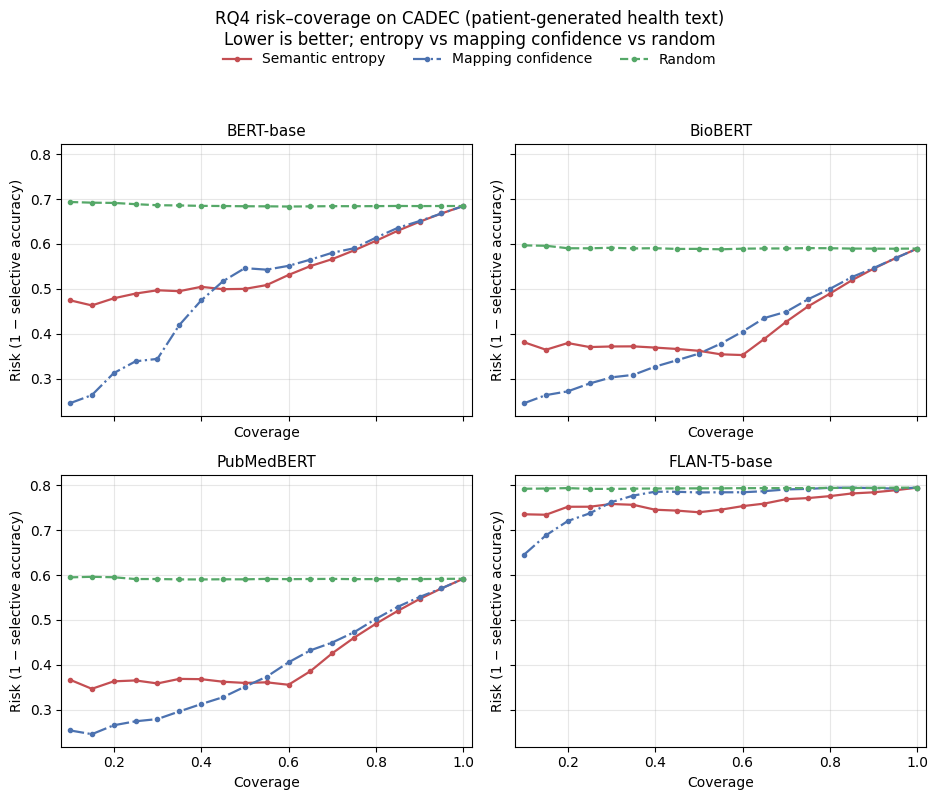

Saved /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/figures/rq4_risk_coverage_cadec.png


In [3]:
# === RQ4 RISK–COVERAGE PLOT (three-way) ======================================
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.5), sharex=True, sharey=True)
axes = axes.ravel()

_plot_specs = [
    ("entropy", "-", "#C44E52", "Semantic entropy"),
    ("mapping_confidence", "-.", "#4C72B0", "Mapping confidence"),
    ("random", "--", "#55A868", "Random"),
]

for ax, model in zip(axes, CLEAN_MODELS):
    sub = df_curves[df_curves["model"] == model]
    for signal, style, color, label in _plot_specs:
        s = sub[sub["signal"] == signal].sort_values("coverage")
        ax.plot(
            s["coverage"], s["risk"],
            linestyle=style, marker="o", ms=3, lw=1.6,
            color=color, label=label,
        )
    ax.set_title(model, fontsize=11)
    ax.set_xlabel("Coverage")
    ax.set_ylabel("Risk (1 − selective accuracy)")
    ax.set_xlim(0.08, 1.02)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    "RQ4 risk–coverage on CADEC (patient-generated health text)\n"
    "Lower is better; entropy vs mapping confidence vs random",
    y=1.06, fontsize=12,
)
plt.tight_layout()
_fig = FIG_DIR / "rq4_risk_coverage_cadec.png"
fig.savefig(_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {_fig}")

## AURC summary and selective accuracy at key coverages

Report AURC for entropy / mapping confidence / random, plus `mapping_confidence` std.
Assert selective accuracy at 50% coverage (entropy ranking) exceeds accuracy at 100%.

In [4]:
# === RQ4 SUMMARY + ASSERT ====================================================
KEY_COVERAGES = [1.00, 0.75, 0.50, 0.25]

print("=== CADEC (patient-generated health text): three-way AURC ===")
print("Columns: model, AURC_entropy, AURC_confidence, AURC_random, mapping_confidence_std")
_aurc_show = df_aurc.set_index("model").loc[CLEAN_MODELS][
    ["AURC_entropy", "AURC_confidence", "AURC_random", "mapping_confidence_std"]
]
display(_aurc_show.round(4))

# Saturation note — mapping confidence collapses as a ranker when nearly constant
_conf_stats = (
    df.groupby("model_name")["mapping_confidence"]
    .agg(mean="mean", std="std", q25=lambda s: s.quantile(0.25),
         q50="median", q75=lambda s: s.quantile(0.75), mx="max")
    .loc[CLEAN_MODELS]
)
print("\n=== mapping_confidence distribution (clean models) ===")
display(_conf_stats.round(4))
print(
    "NOTE: mapping confidence is saturated (std ~0.01–0.04 across clean models, "
    "Q3 at 1.0) and therefore behaves near-randomly as a ranker — AURC_confidence ≈ AURC_random."
)

print("\n=== Selective accuracy at key coverages (entropy ranking) ===")
summary_rows = []
for model in CLEAN_MODELS:
    ent = df_curves[(df_curves["model"] == model) & (df_curves["signal"] == "entropy")]
    row = {"model": model}
    for cov in KEY_COVERAGES:
        match = ent.loc[np.isclose(ent["coverage"], cov), "selective_accuracy"]
        if match.empty:
            raise ValueError(f"Missing coverage {cov} for {model}")
        row[f"acc@{cov:.0%}"] = float(match.iloc[0])
    ar = df_aurc.loc[df_aurc["model"] == model].iloc[0]
    row["AURC_entropy"] = float(ar["AURC_entropy"])
    row["AURC_confidence"] = float(ar["AURC_confidence"])
    row["AURC_random"] = float(ar["AURC_random"])
    row["mapping_confidence_std"] = float(ar["mapping_confidence_std"])
    summary_rows.append(row)

    print(
        f"{model}: AURC_entropy={row['AURC_entropy']:.4f} | "
        f"AURC_confidence={row['AURC_confidence']:.4f} | "
        f"AURC_random={row['AURC_random']:.4f} | "
        f"conf_std={row['mapping_confidence_std']:.4f} | "
        f"acc@100%={row['acc@100%']:.4f} | @75%={row['acc@75%']:.4f} | "
        f"@50%={row['acc@50%']:.4f} | @25%={row['acc@25%']:.4f}"
    )

df_summary = pd.DataFrame(summary_rows)
display(df_summary.set_index("model").round(4))

# Assert: entropy abstention helps — selective accuracy @ 50% > accuracy @ 100%
for model in CLEAN_MODELS:
    acc100 = float(df_summary.loc[df_summary["model"] == model, "acc@100%"].iloc[0])
    acc50 = float(df_summary.loc[df_summary["model"] == model, "acc@50%"].iloc[0])
    assert acc50 > acc100, (
        f"ASSERT FAIL [{model}]: selective accuracy at 50% coverage ({acc50:.4f}) "
        f"did not exceed accuracy at 100% coverage ({acc100:.4f})."
    )
    print(f"ASSERT OK [{model}]: acc@50% ({acc50:.4f}) > acc@100% ({acc100:.4f})")

print(
    f"\nArtifacts:\n  {OUT_DIR / 'rq4_risk_coverage_cadec.csv'}\n"
    f"  {FIG_DIR / 'rq4_risk_coverage_cadec.png'}"
)

=== CADEC (patient-generated health text): three-way AURC ===
Columns: model, AURC_entropy, AURC_confidence, AURC_random, mapping_confidence_std


,AURC_entropy,AURC_confidence,AURC_random,mapping_confidence_std
model,,,,
BERT-base,0.4900,0.4538,0.6171,0.0128
BioBERT,0.3772,0.3580,0.5313,0.0121
PubMedBERT,0.3745,0.3532,0.5325,0.0144
FLAN-T5-base,0.6839,0.6938,0.7141,0.0394



=== mapping_confidence distribution (clean models) ===


,mean,std,q25,q50,q75,mx
model_name,,,,,,
BERT-base,0.9973,0.0128,1.0,1.0,1.0,1.0
BioBERT,0.9977,0.0121,1.0,1.0,1.0,1.0
PubMedBERT,0.9972,0.0144,1.0,1.0,1.0,1.0
FLAN-T5-base,0.9911,0.0394,1.0,1.0,1.0,1.0


NOTE: mapping confidence is saturated (std ~0.01–0.04 across clean models, Q3 at 1.0) and therefore behaves near-randomly as a ranker — AURC_confidence ≈ AURC_random.

=== Selective accuracy at key coverages (entropy ranking) ===
BERT-base: AURC_entropy=0.4900 | AURC_confidence=0.4538 | AURC_random=0.6171 | conf_std=0.0128 | acc@100%=0.3156 | @75%=0.4144 | @50%=0.5002 | @25%=0.5106
BioBERT: AURC_entropy=0.3772 | AURC_confidence=0.3580 | AURC_random=0.5313 | conf_std=0.0121 | acc@100%=0.4103 | @75%=0.5390 | @50%=0.6381 | @25%=0.6298
PubMedBERT: AURC_entropy=0.3745 | AURC_confidence=0.3532 | AURC_random=0.5325 | conf_std=0.0144 | acc@100%=0.4082 | @75%=0.5395 | @50%=0.6402 | @25%=0.6347
FLAN-T5-base: AURC_entropy=0.6839 | AURC_confidence=0.6938 | AURC_random=0.7141 | conf_std=0.0394 | acc@100%=0.2052 | @75%=0.2284 | @50%=0.2601 | @25%=0.2477


,acc@100%,acc@75%,acc@50%,acc@25%,AURC_entropy,AURC_confidence,AURC_random,mapping_confidence_std
model,,,,,,,,
BERT-base,0.3156,0.4144,0.5002,0.5106,0.4900,0.4538,0.6171,0.0128
BioBERT,0.4103,0.5390,0.6381,0.6298,0.3772,0.3580,0.5313,0.0121
PubMedBERT,0.4082,0.5395,0.6402,0.6347,0.3745,0.3532,0.5325,0.0144
FLAN-T5-base,0.2052,0.2284,0.2601,0.2477,0.6839,0.6938,0.7141,0.0394


ASSERT OK [BERT-base]: acc@50% (0.5002) > acc@100% (0.3156)
ASSERT OK [BioBERT]: acc@50% (0.6381) > acc@100% (0.4103)
ASSERT OK [PubMedBERT]: acc@50% (0.6402) > acc@100% (0.4082)
ASSERT OK [FLAN-T5-base]: acc@50% (0.2601) > acc@100% (0.2052)

Artifacts:
  /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/rq4_risk_coverage_cadec.csv
  /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/figures/rq4_risk_coverage_cadec.png
